Loaded 152 rows | 24 wells | DIV 5-27


/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/

LMM: Active_area ~ NeuronType * DIV + (1 | CHIP_WELL)
Reference: MxWT   |   n wells: 24

  Effect                                χ²   df          p       
  -------------------------------- -------  ---  ---------  -----
  Genotype (main effect)             0.030    2     0.9853     ns
  Genotype × DIV (trajectory)        3.204    2     0.2015     ns

  ── Interpretation ───────────────────────────────────────────
  ✓ No significant genotype effect on Active Area.
    → Absolute-threshold QC is defensible.

  ── Pairwise Wald tests (full model) ─────────────────────────
  Comparison                         z          p       
  ---------------------------- -------  ---------  -----
  MxWT vs FxHET                  1.346     0.1784     ns
  MxWT vs MxHEMI                 1.450     0.1470     ns
  FxHET vs MxHEMI                0.381     0.7031     ns

  ── Fixed-effect coefficients (full model, ref=MxWT) ────────
                                                 Coef. Std.Err.       z  P

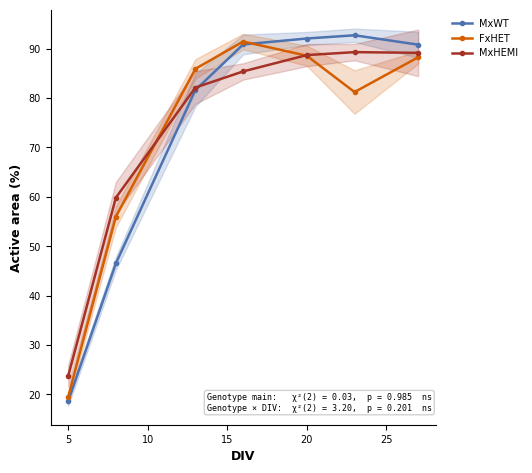

Floor filter (<30.0%): 0 wells excluded
DIV coverage filter (<4 timepoints): 0 wells excluded
Marked 3 MAD-based outliers (|modZ| > 3.5)
Flagged 2 residual dips (late DIV >= 14, modZ < -3.5)
  below_floor: 0 rows flagged
  insufficient_divs: 0 rows flagged
  is_outlier: 3 rows flagged
  is_bad_residual: 2 rows flagged
Total excluded: 4 / 152 (2.6%)
DIV         5   8   13  16  20  23  27
NeuronType                            
FxHET        9   8   9   9   9   8   2
MxHEMI       4   4   4   4   4   4   2

Wells per NeuronType x DIV:
DIV         5   8   13  16  20  23  27
NeuronType                            
FxHET        9   8   9   9   9   8   2
MxHEMI       4   4   4   4   4   4   2
MxWT        11  11  10  10  11  11   4


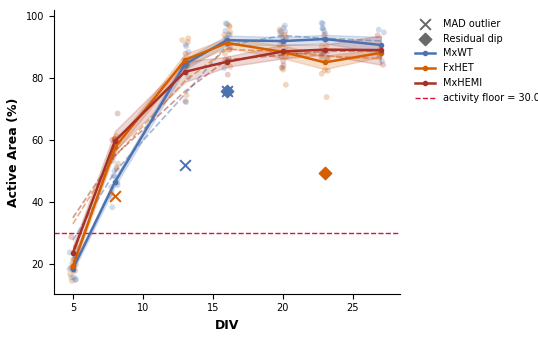


=== Floor / DIV excluded wells ===
Empty DataFrame
Columns: [NeuronType, CHIP_WELL, below_floor, insufficient_divs]
Index: []

=== MAD Outliers ===
NeuronType  DIV CHIP_WELL  Active_area
     FxHET    8  M07420_5    42.015152
      MxWT   13  M07039_5    52.060606
      MxWT   16  M07039_5    76.045455

=== Residual Dips ===
NeuronType  DIV CHIP_WELL  Active_area  expected_y  resid_expected
     FxHET   23  M07420_6    49.545455   87.202020      -37.656566
      MxWT   16  M07039_5    76.045455   90.623737      -14.578283


In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from activity_qc_plotter import plot_active_area_trajectory, test_genotype_lmm


# ==============================
# 1  DATA LOADING
# ==============================
def load_mea_data(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df['DIV'] = df['DIV'].astype(int)
    df['Chip_ID'] = df['Chip_ID'].astype(str)
    df['Well'] = df['Well'].astype(str)
    df['NeuronType'] = df['NeuronType'].astype(str)
    df['Active_area'] = pd.to_numeric(df['Active_area'], errors='coerce')
    df['CHIP_WELL'] = df['Chip_ID'] + '_' + df['Well']
    df = df.dropna(subset=['Active_area']).copy()
    return df


# ==============================
# 2  FLOOR FILTER (per well)
# ==============================
def filter_below_floor(
    df: pd.DataFrame,
    value_col: str = 'Active_area',
    floor: float = 30.0,
) -> pd.DataFrame:
    df = df.copy()
    well_max = df.groupby('CHIP_WELL')[value_col].transform('max')
    df['below_floor'] = well_max < floor
    n_wells = df[df['below_floor']]['CHIP_WELL'].nunique()
    print(f'Floor filter (<{floor}%): {n_wells} wells excluded')
    return df


# ==============================
# 3  DIV COVERAGE FILTER (per well)
# ==============================
def filter_insufficient_divs(
    df: pd.DataFrame,
    min_divs: int = 4,
) -> pd.DataFrame:
    df = df.copy()
    well_ndivs = df.groupby('CHIP_WELL')['DIV'].transform('nunique')
    df['insufficient_divs'] = well_ndivs < min_divs
    n_wells = df[df['insufficient_divs']]['CHIP_WELL'].nunique()
    print(f'DIV coverage filter (<{min_divs} timepoints): {n_wells} wells excluded')
    return df


# ==============================
# 4  MAD OUTLIERS (per NeuronType x DIV, on pre-filtered wells only)
# ==============================
def detect_outliers_within_groups(
    df: pd.DataFrame,
    value_col: str = 'Active_area',
    min_n: int = 5,
    z_thresh: float = 3.5,
) -> pd.DataFrame:
    df = df.copy()
    df['is_outlier'] = False
    for (nt, div), group in df.groupby(['NeuronType', 'DIV'], sort=False):
        vals = group[value_col].to_numpy(dtype=float)
        if vals.size < min_n:
            continue
        med = np.median(vals)
        mad = np.median(np.abs(vals - med))
        if mad <= 0:
            continue
        modz = 0.6745 * (vals - med) / mad
        df.loc[group.index[np.abs(modz) > z_thresh], 'is_outlier'] = True
    print(f'Marked {int(df["is_outlier"].sum())} MAD-based outliers (|modZ| > {z_thresh})')
    return df


# ==============================
# 5  EXPECTED-CURVE RESIDUAL DIPS (per NeuronType, on pre-filtered wells only)
# ==============================
def _moving_average(y: np.ndarray, window: int = 3) -> np.ndarray:
    if window <= 1:
        return y
    y = np.asarray(y, dtype=float)
    pad = window // 2
    ypad = np.pad(y, (pad, pad), mode='edge')
    return np.convolve(ypad, np.ones(window) / window, mode='valid')


def detect_expected_curve_residuals(
    df: pd.DataFrame,
    value_col: str = 'Active_area',
    late_div_min: int = 14,
    min_div_points: int = 4,
    smooth_window: int = 3,
    resid_modz_thresh: float = 3.5,
    build_expected_from_non_outliers: bool = True,
) -> pd.DataFrame:
    df = df.copy()
    df['expected_y']      = np.nan
    df['resid_expected']  = np.nan
    df['is_bad_residual'] = False
    for nt, sub_all in df.groupby('NeuronType', sort=False):
        sub_fit = (
            sub_all[~sub_all['is_outlier']].copy()
            if build_expected_from_non_outliers and 'is_outlier' in df.columns
            else sub_all.copy()
        )
        div_meds = sub_fit.groupby('DIV')[value_col].median()
        if div_meds.shape[0] < min_div_points:
            continue
        divs        = div_meds.index.to_numpy(dtype=int)
        meds_smooth = _moving_average(div_meds.to_numpy(dtype=float), window=smooth_window)
        expected_map = dict(zip(divs, meds_smooth))
        idx_nt  = df['NeuronType'] == nt
        df.loc[idx_nt, 'expected_y'] = df.loc[idx_nt, 'DIV'].map(expected_map)
        has_exp = idx_nt & df['expected_y'].notna()
        df.loc[has_exp, 'resid_expected'] = (
            df.loc[has_exp, value_col] - df.loc[has_exp, 'expected_y']
        )
        cand  = has_exp & (df['DIV'] >= late_div_min)
        resid = df.loc[cand, 'resid_expected'].to_numpy(dtype=float)
        if resid.size < 5:
            continue
        med_r = np.median(resid)
        mad_r = np.median(np.abs(resid - med_r))
        if mad_r <= 0:
            continue
        modz_r = 0.6745 * (resid - med_r) / mad_r
        df.loc[df.loc[cand].index[modz_r < -resid_modz_thresh], 'is_bad_residual'] = True
    print(f'Flagged {int(df["is_bad_residual"].sum())} residual dips '
          f'(late DIV >= {late_div_min}, modZ < -{resid_modz_thresh})')
    return df


# ==============================
# 6  COMBINE FLAGS
# ==============================
def mark_filtered(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    flag_cols = [c for c in ['below_floor', 'insufficient_divs', 'is_outlier', 'is_bad_residual']
                 if c in df.columns]
    df['to_exclude'] = df[flag_cols].any(axis=1)
    for col in flag_cols:
        print(f'  {col}: {int(df[col].sum())} rows flagged')
    print(f'Total excluded: {df["to_exclude"].sum()} / {len(df)} '
          f'({df["to_exclude"].mean()*100:.1f}%)')
    return df


# ==============================
# 7  BALANCE CHECK (wells per NeuronType x DIV after curation)
# ==============================
def check_balance(df: pd.DataFrame, min_n: int = 3) -> pd.DataFrame:
    clean = df[~df['to_exclude']]
    bal = (clean.groupby(['NeuronType', 'DIV'])['CHIP_WELL']
           .nunique()
           .unstack('DIV')
           .fillna(0)
           .astype(int))
    low = (bal < min_n) & (bal > 0)
    if low.any().any():
        print(f'WARNING: NeuronType×DIV cells with <{min_n} wells:')
        print(bal[low.any(axis=1)])
    else:
        print(f'Balance OK: all groups >=={min_n} wells per DIV')
    print('\nWells per NeuronType x DIV:')
    print(bal.to_string())
    return bal


# ==============================
# 8  CONFIG  <-- edit paths and thresholds here
# ==============================
CSV_PATH  = '/Users/mandarmp/Documents/PHD/HD_MEA_PAPERWITHCDKL5/Fig2/ActivityScan_outputs/Compiled_Activity_Summary_updated.csv'
SAVE_DIR  = '/Users/mandarmp/Documents/PHD/HD_MEA_PAPERWITHCDKL5/Fig2/ActivityScan_outputs/'

GROUP_ORDER = ['MxWT', 'FxHET', 'MxHEMI']
PALETTE     = {'MxWT': '#4C72B0', 'FxHET': '#D55E00', 'MxHEMI': '#A63226'}

FLOOR_PCT = 30.0   # wells never exceeding this % active area -> dead culture
MIN_DIVS  = 4      # minimum DIV timepoints required per well


# ==============================
# STEP 1 -- load raw data
# ==============================
df_raw = load_mea_data(CSV_PATH)
print(f'Loaded {len(df_raw)} rows | {df_raw["CHIP_WELL"].nunique()} wells | '
      f'DIV {df_raw["DIV"].min()}-{df_raw["DIV"].max()}')


# ==============================
# STEP 2 -- LMM genotype test on raw data (before any filtering)
#    Model: Active_area ~ Genotype * DIV + (1 | CHIP_WELL)
#    LRT 1: main genotype effect
#    LRT 2: genotype x DIV interaction
# ==============================
fig_lmm, ax_data, ax_fit, lrt = test_genotype_lmm(
    df_raw,
    group_order=GROUP_ORDER,
    palette=PALETTE,
    figsize=(5.5, 5.0),
    save_path=os.path.join(SAVE_DIR, 'ActiveArea_genotype_lmm.svg'),
)
plt.show()


# ==============================
# STEP 3 -- well-level pre-filters (floor + DIV coverage)
#           then MAD + residual on passing wells only
#           (avoids dead wells skewing group medians)
# ==============================
df = filter_below_floor(df_raw, floor=FLOOR_PCT)
df = filter_insufficient_divs(df, min_divs=MIN_DIVS)

pre_ok = ~df['below_floor'] & ~df['insufficient_divs']
df_valid = df[pre_ok].copy()
df_valid = detect_outliers_within_groups(df_valid, z_thresh=3.5)
df_valid = detect_expected_curve_residuals(df_valid, late_div_min=14,
                                            smooth_window=3, resid_modz_thresh=3.5)

for col in ['is_outlier', 'is_bad_residual']:
    df[col] = False
    df.loc[df_valid.index, col] = df_valid[col]
for col in ['expected_y', 'resid_expected']:
    df[col] = np.nan
    df.loc[df_valid.index, col] = df_valid[col]

df = mark_filtered(df)


# ==============================
# STEP 4 -- balance check
# ==============================
balance_table = check_balance(df, min_n=3)


# ==============================
# STEP 5 -- QC trajectory plot
# ==============================
fig_qc, _ = plot_active_area_trajectory(
    df,
    group_order=GROUP_ORDER,
    palette=PALETTE,
    figsize=(5.5, 3.5),
    show_expected=True,
    show_threshold=FLOOR_PCT,
    threshold_label='activity floor',
    ylabel='Active Area (%)',
    save_path=os.path.join(SAVE_DIR, 'ActiveArea_Trajectory_QC.svg'),
)
plt.show()

print('\n=== Floor / DIV excluded wells ===')
excl = df[df['below_floor'] | df['insufficient_divs']]
print(excl[['NeuronType', 'CHIP_WELL', 'below_floor', 'insufficient_divs']]
      .drop_duplicates('CHIP_WELL').sort_values('NeuronType').to_string(index=False))

print('\n=== MAD Outliers ===')
print(df[df['is_outlier']][['NeuronType', 'DIV', 'CHIP_WELL', 'Active_area']]
      .sort_values(['NeuronType', 'DIV']).to_string(index=False))

print('\n=== Residual Dips ===')
print(df[df['is_bad_residual']][['NeuronType', 'DIV', 'CHIP_WELL',
                                   'Active_area', 'expected_y', 'resid_expected']]
      .sort_values(['NeuronType', 'DIV']).to_string(index=False))


In [2]:
df_raw["CHIP_WELL"].unique()

array(['M07039_1', 'M07039_2', 'M07039_3', 'M07039_4', 'M07039_5',
       'M07039_6', 'M07420_1', 'M07427_1', 'M07427_2', 'M07427_3',
       'M07427_4', 'M07427_5', 'M07427_6', 'M08018_1', 'M08018_2',
       'M08018_3', 'M08018_4', 'M08018_5', 'M08018_6'], dtype=object)